In [1]:
# libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import json


import seaborn as sns
from matplotlib.lines import Line2D


from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance



In [2]:
labels = [# 'human',
          'gpt_5.1',
          'gpt_5.4',
          'gpt_5.4_mini',
          'gpt_5.4_nano',
          'Llama_3.3_70B_Instruct',
          'Gemma_4_31B',
          'Qwen3.5_27B',
          'Qwen3.5_9B',
          ]

In [3]:
# parameters of file
task = 'cg'
values = [0, 140]
v = 1
n = 3

framed = False

there are 27 nans over 54 elements
there are 18 nans over 54 elements
there are 27 nans over 54 elements
there are 18 nans over 54 elements
there are 27 nans over 54 elements
there are 18 nans over 54 elements
there are 27 nans over 54 elements
there are 16 nans over 54 elements
there are 2 nans over 54 elements
there are 9 nans over 54 elements
there are 7 nans over 54 elements
there are 22 nans over 54 elements
there are 12 nans over 54 elements
there are 22 nans over 54 elements
there are 9 nans over 54 elements
there are 27 nans over 54 elements
there are 18 nans over 54 elements
there are 24 nans over 54 elements
there are 18 nans over 54 elements


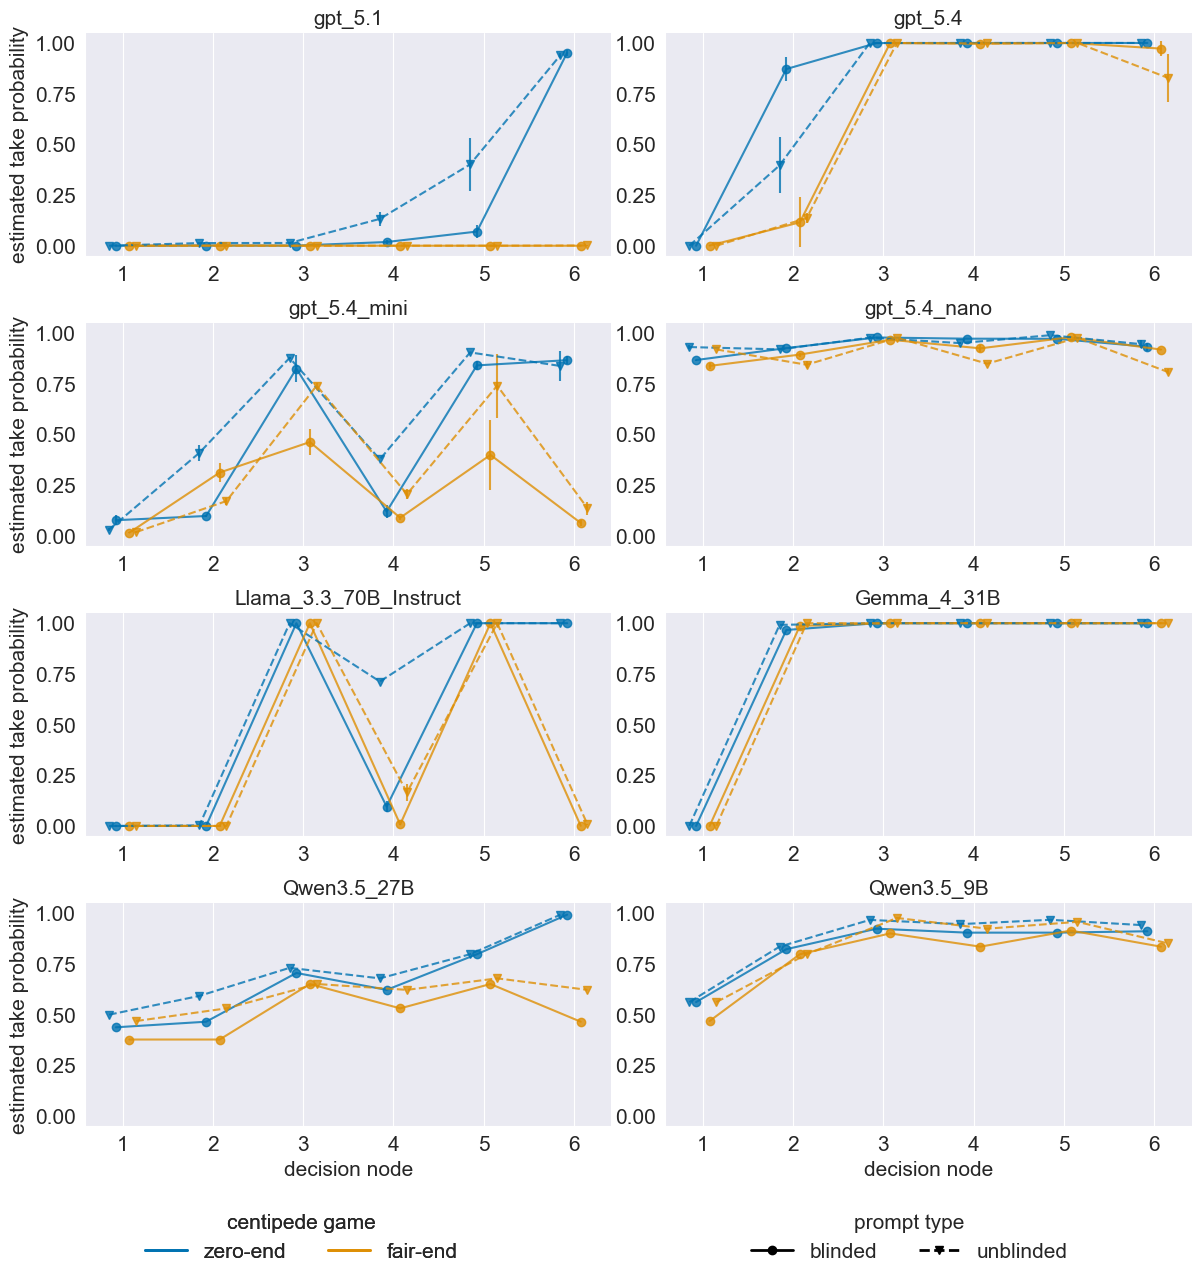

In [13]:
project_dir = os.path.abspath("..")

width = .075
support = np.arange(1,7)

take = 'X'


refs = {0: np.array([0.19512195, 0.25609756, 0.26219512, 0.16463415, 0.07317073, 0.04268293, 0.00609756], dtype=float),
        140: np.array([0.22222222, 0.20061728, 0.10493827, 0.09259259, 0.10185185, 0.0308642 , 0.24691358], dtype=float)
        }

refs_take_prob = {key: [ref[i]/ref[i:].sum() for i in range(len(ref)-1)] for key, ref in refs.items()}

markers = ['o', 'v']
linestyles = ['-', '--']
colors = dict(zip(values, sns.color_palette("colorblind", len(values))))

cgs = {0: 'zero-end', 140: 'fair-end'}


fig, ax = plt.subplots(len(labels)//2, 2, figsize=(12, 12))

ax[-1, 0].set_xlabel('decision node', fontsize=15)
ax[-1, 1].set_xlabel('decision node', fontsize=15)

for row in range(len(labels)//2):
    ax[row, 0].set_ylabel('estimated take probability', fontsize=15)

for z, label in enumerate(labels):
    ax[z//2, z%2].set_ylim(-0.05, 1.05)
    ax[z//2, z%2].set_xticks(support)
    ax[z//2, z%2].set_xticklabels(support)

    ax[z//2, z%2].set_title(label, fontsize=15)
    # ax[z//2, z%2].set_xlabel('decision node', fontsize=15)
    # ax[z//2, z%2].set_ylabel('take probability', fontsize=15)
    ax[z//2, z%2].grid(axis='y')
    ax[z//2, z%2].spines[["top", "right"]].set_visible(False)
    ax[z//2, z%2].tick_params(axis="both", which="major", labelsize=15)
    
    n=3
    if label == 'Qwen3.5_27B':
        n=9
    
    for i, blinded in enumerate(['blinded', 'unblinded']):
        for j, value in enumerate(values):
            # print(label)
            file_name = f'{label}-cg-{value}-v{v}-n{n}-{blinded}-seq.json'
            
            path_to_file = os.path.join(project_dir, 'output', file_name)
            with open(path_to_file, encoding='utf-8') as f:
                 data = json.load(f)
                
            
            ref = refs[value]
            ref_take_probs = refs_take_prob[value]
            
            # ax[z//2, z%2].scatter(support, ref_take_probs,
            #            marker='*', 
            #            color=colors[value],
            #            alpha=0.8,
            #          )
        
            
        
            take_probability = np.zeros(len(support), dtype=float)
            std_take_probability = np.zeros(len(support), dtype=float)
            
            for role in ['A', 'B']:
                nan_count = 0
                count = 0
                for k, sample_dict_list in data[f'role{role}'].items():
                    # print(k, '\n')
                    mean_take_values = []
                    std_take_values = []
                    for sample_dict in sample_dict_list:
                        # print(sample_dict)
                        take_values = []
                        for sample, sample_values in sample_dict.items():
                            # print(sample, sample_values)
                            count += 1
                            if sample_values['X'] is None and sample_values['Y'] is None:
                                print('both values are nans so we set them to 0.5')
                                nan_count += 2
                                sample_values['X'] = .5
                                sample_values['Y'] = .5
                            elif sample_values['X'] is None:
                                # print('X is nan so we set it to 1-Y')
                                nan_count += 1
                                sample_values['X'] = 1 - sample_values['Y']
                            elif sample_values['Y'] is None:
                                # print('Y is nan so we set it to 1-X')
                                nan_count += 1
                                sample_values['Y'] = 1 - sample_values['X']
                                
                            sample_values['X'] = np.clip(sample_values['X'], 0, 1)
                            sample_values['Y'] = np.clip(sample_values['Y'], 0, 1)
                            
                            somma = sample_values['X'] + sample_values['Y']
                            sample_values['X'] /= somma
                            sample_values['Y'] /= somma
                            take_values.append(sample_values[take])
                        mean_take_values.append(np.mean(take_values))
                        std_take_values.append(np.std(take_values))
                    take_probability[int(k)-1] = np.mean(mean_take_values)
                    std_take_probability[int(k)-1] = np.mean(std_take_values)
                if nan_count > 0:
                    print(f'there are {nan_count} nans over {2*count} elements')
                    


            offset = (2*j-1)*(i+1) * width
            ax[z//2, z%2].errorbar(support+offset, take_probability, std_take_probability,
                       marker=markers[i], 
                       linestyle=linestyles[i],
                       color=colors[value],
                       alpha=0.8,
                     )
            
cg_handles = [
Line2D([0], [0], 
   color=colors[value],
   linewidth=2, 
   label=cgs[value],
   )
for value in values
]

prompt_handles = [
    Line2D([0], [0],
        color="black",
        linestyle=linestyles[t],
        linewidth=2,
        marker=markers[t],
        label=prompt,
    )
    for t, prompt in enumerate(['blinded', 'unblinded'])
] 

model_legend = fig.legend(
    handles=cg_handles,
    title="centipede game",
    bbox_to_anchor=(0.1, 0.),
    loc="upper left",
    frameon=False,
    fontsize=15,
    ncol=2,
    title_fontsize=15,
    handlelength=2,
)

fig.add_artist(model_legend)

fig.legend(
    handles=prompt_handles,
    title="prompt type",
    bbox_to_anchor=(.9, 0.),
    loc="upper right",
    frameon=False,
    fontsize=15,
    ncol=2,
    title_fontsize=15,
    handlelength=2,
)

  

plt.tight_layout()                          

name = f'res1-v{v}-n{n}.pdf'
path_to_fig = os.path.join(project_dir, 'figures', name)
plt.savefig(path_to_fig, format='pdf', bbox_inches='tight')

plt.show()
        